##**[Google Colaboratory] 実行系のショートカットキー**
1. セルの実行：Ctrl＋Enter
2. 全セルの実行：Ctr＋F9
3. 実行中断：Ctrl＋M＋I

##**■生存時間分析による離反時期分析 その4**
###**Pythonの生存時間分析ライブラリLifelinesで実施する「離反時期(顧客であるまでの期間)分析**

[参考サイト](https://www.salesanalytics.co.jp/datascience/datascience075/)

###**サンプルデータのダウンロード**

**通信会社の顧客の離反データ**（Kaggleのサンプルデータ）を使用  
以下の**Kaggle**のサイトからCSVファイルをダウンロードする  

[サンプルデータ](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

###**通信会社の顧客の離反データ**

[データセットの構成]
1. **生存時間(契約期間)：tenure**
2. **イベント生起(離反)：Churn**
3. **いくつかの特徴量（説明変数X）**  

    ・customerID：個人を識別するID  
    ・gender：性別  
    ・SeniorCitizen：シニア  
    ・Partner：  
    ・Dependents：扶養家族  
    ・tenure：契約期間  
    ・PhoneService：電話サービス  
    ・MulitipleLines：  
    ・InternetService：  
    ・OnlineSecurity：  
    ・OnlineBackup：  
    ・DeviceProtection：  
    ・TechSupport：  
    ・StreamingTV：  
    ・StreamingMovies：  
    ・Contract：契約内容  
    ・PaperlessBilling：  
    ・PaymentMethod：支払方法  
    ・MonthlyCharges：月額料金  
    ・TotalCharges：合計請求額  
    ・**Churn：解約**  

[分析方法]
1. **カプランマイヤー推定法**
2. **Lasso（スパースモデリング）**  

[全体の流れ]
1. **ライブラリーの読み込み**
2. **データセットの読み込み**
3. **各特徴量の確認(EDA)**  
4. **前処理**  
5. **データセットの分割（学習データとテストデータ）**
6. **学習データでモデル構築**
7. **テストデータで精度検証**
8. **継続顧客（離反していない顧客）の離反時期予測**  

[本ノートブックの対応箇所]
1. **ライブラリーの読み込み**
2. **データセットの読み込み**
3. **各特徴量の確認(EDA)　→　★ 目的 ★**  


###**0. ライブラリ「Lifelines」のインストール**

In [66]:
!pip install lifelines

###**1. ライブラリの読み込み**

In [67]:
# 必要なライブラリーの読み込み
import pandas as pd
import numpy as np
from lifelines import *
from lifelines.utils import median_survival_times

# データ描画ライブラリをインポート
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# グラフのスタイル
plt.style.use('ggplot')

# グラフサイズ設定
plt.rcParams['figure.figsize'] = [12, 9]

###**2. データセットの読み込み**

In [68]:
# Google Driveのマウント
from google.colab import drive
drive.mount('/content/drive')

# コピーしたパスを貼り付けてください
file_path = '/content/drive/MyDrive/Kaggle/02_Telco-Customer-Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# CSVファイルを読み込む
df = pd.read_csv(file_path)

# データの確認
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [69]:
# データセットの状況を確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [70]:
# 上記をグループ化してみる
df.columns.to_series().groupby(df.dtypes).groups


{int64: ['SeniorCitizen', 'tenure'], float64: ['MonthlyCharges'], object: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']}

###**3. 各特徴量の確認(EDA）**

####**1) 件数を確認**

In [71]:
# 最初の列を除いたすべての列を選択
for elem in df.columns[1:]:
    print(df[elem].value_counts())
    print("\n")


gender
Male      3555
Female    3488
Name: count, dtype: int64


SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


Partner
No     3641
Yes    3402
Name: count, dtype: int64


Dependents
No     4933
Yes    2110
Name: count, dtype: int64


tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64


PhoneService
Yes    6361
No      682
Name: count, dtype: int64


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


DeviceProtection
No                     3095
Yes       

####**2) TotalChargesに対する前処理**

In [72]:
# TotalCharges変数を型変換（数値型へ）
df.TotalCharges = pd.to_numeric(df.TotalCharges,
                                errors='coerce')

 # データセット状況の確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


####**3) SeniorCitizenに対する前処理**
int型になっているが、カテゴリカルデータと感がられるのでobject型に変換する

In [73]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype("object")

# データの確認
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


####**4) Churnに対する前処理**

In [74]:
# Churnの値変換（Yes:1、No:0）
df = df.replace({'Churn':{'Yes':1, 'No':0}})

# データの確認
df

<ipython-input-74-dd1270ffe104>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Churn':{'Yes':1, 'No':0}})


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


####**5) 欠損値の確認**

In [75]:
# 欠損値の確認
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [76]:
# 欠損値のある行を分析対象から削除する
df = df.dropna(how='any')

# 欠損値の確認
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


####**6) Exploratory Data Analysis（探索的データ分析）**

In [77]:
# 量的データの統計量を確認
df.describe()


,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,0.265785
std,24.545260,30.085974,2266.771362,0.441782
min,1.000000,18.250000,18.800000,0.000000
25%,9.000000,35.587500,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.862500,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


####**(1) Churnの分布**

Churn
0    5163
1    1869
Name: count, dtype: int64


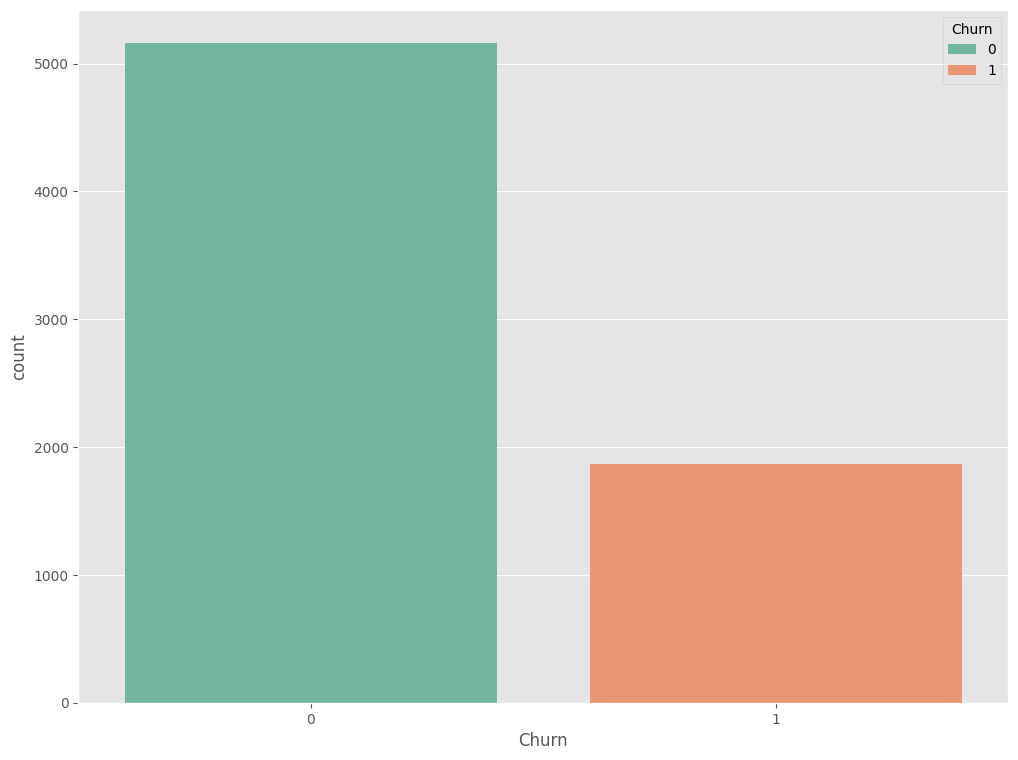

In [78]:
# Churnの数
print(df['Churn'].value_counts())

# データの可視化
sns.countplot(x='Churn', hue='Churn', data=df, palette='Set2')
plt.show()

####**(2) 数値データ（契約期間、月額料金、合計請求額）の確認**

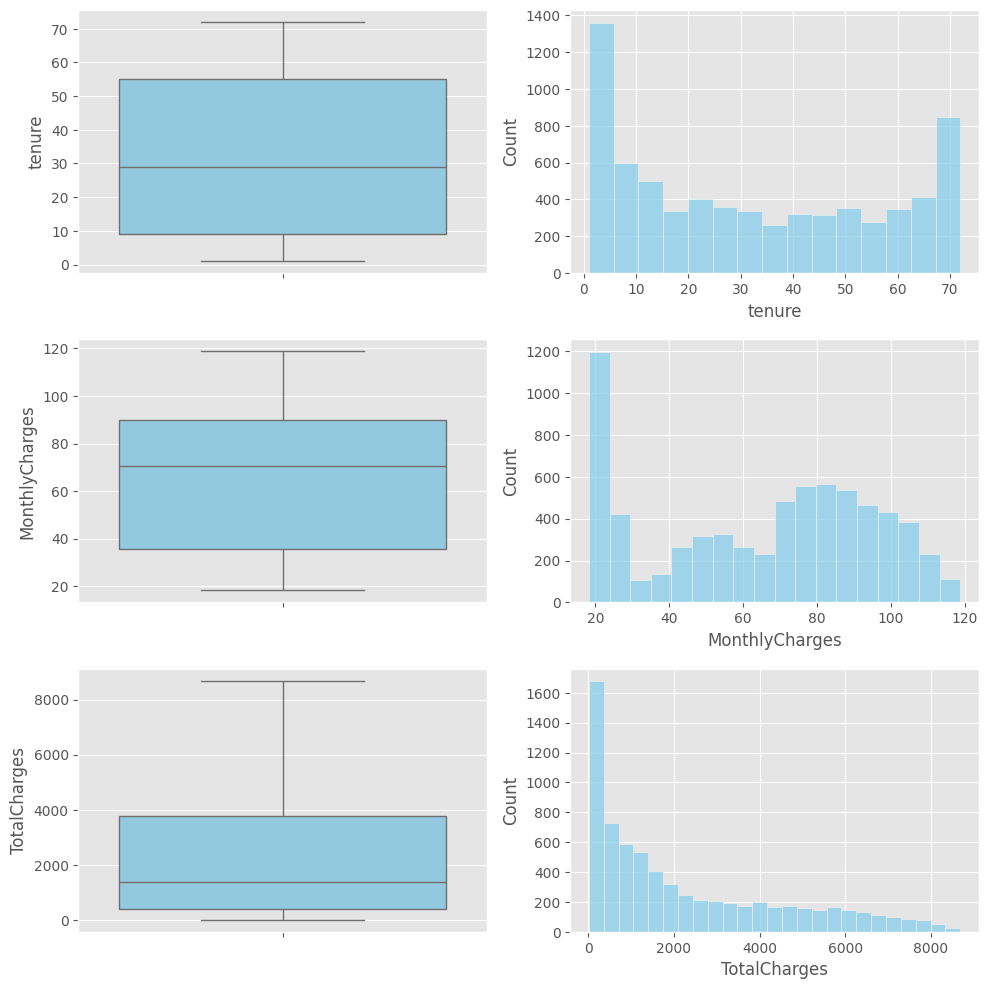

In [79]:
# 図のサイズを設定
plt.figure(figsize=(10,10))
# 全体を3行、2列にわけて、1番目のサブプロットを選択
plt.subplot(3, 2, 1)
ax = sns.boxplot(y=df['tenure'], color="skyblue")

# 全体を3行、2列にわけて、2番目のサブプロットを選択
plt.subplot(3, 2, 2)
ax = sns.histplot(x='tenure', data=df, color="skyblue")

# 全体を3行、2列にわけて、3番目のサブプロットを選択
plt.subplot(3, 2, 3)
ax = sns.boxplot(y=df['MonthlyCharges'], color="skyblue")

# 全体を3行、2列にわけて、4番目のサブプロットを選択
plt.subplot(3, 2, 4)
ax = sns.histplot(x='MonthlyCharges', data=df, color="skyblue")

# 全体を3行、2列にわけて、5番目のサブプロットを選択
plt.subplot(3, 2, 5)
ax = sns.boxplot(y= df['TotalCharges'], color="skyblue")

# 全体を3行、2列にわけて、6番目のサブプロットを選択
plt.subplot(3, 2, 6)
ax = sns.histplot(x='TotalCharges', data=df, color="skyblue")

# レイアウトを調整
plt.tight_layout()
plt.show()


####**(3) 数値データ（契約期間、月額料金、合計請求額）毎の解約を確認**

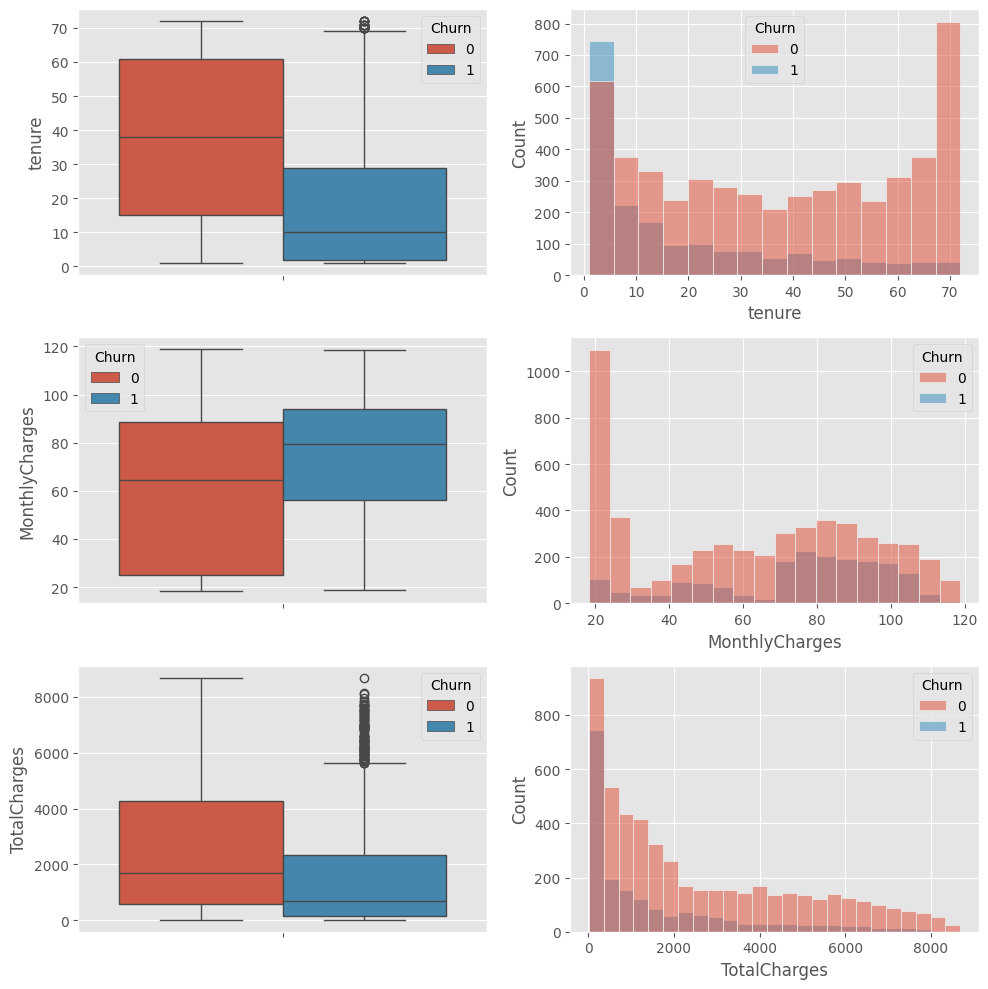

In [80]:
# 図のサイズを設定
plt.figure(figsize=(10,10))
# 全体を3行、2列にわけて、1番目のサブプロットを選択
plt.subplot(3, 2, 1)
ax = sns.boxplot(data=df,y='tenure', hue='Churn')

# 全体を3行、2列にわけて、2番目のサブプロットを選択
plt.subplot(3, 2, 2)
ax = sns.histplot(data=df, x ='tenure', hue='Churn')

# 全体を3行、2列にわけて、3番目のサブプロットを選択
plt.subplot(3, 2, 3)
ax = sns.boxplot(data=df,y='MonthlyCharges', hue='Churn')

# 全体を3行、2列にわけて、4番目のサブプロットを選択
plt.subplot(3, 2, 4)
ax = sns.histplot(data=df, x ='MonthlyCharges', hue='Churn')

# 全体を3行、2列にわけて、5番目のサブプロットを選択
plt.subplot(3, 2, 5)
ax = sns.boxplot(data=df,y='TotalCharges', hue='Churn')

# 全体を3行、2列にわけて、6番目のサブプロットを選択
plt.subplot(3, 2, 6)
ax = sns.histplot(data=df, x ='TotalCharges', hue='Churn')

# レイアウトを調整
plt.tight_layout()
plt.show()

####**(4) 数値データ（月額料金、合計請求額）の関係を散布図で確認、かつ、解約状況も確認**

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

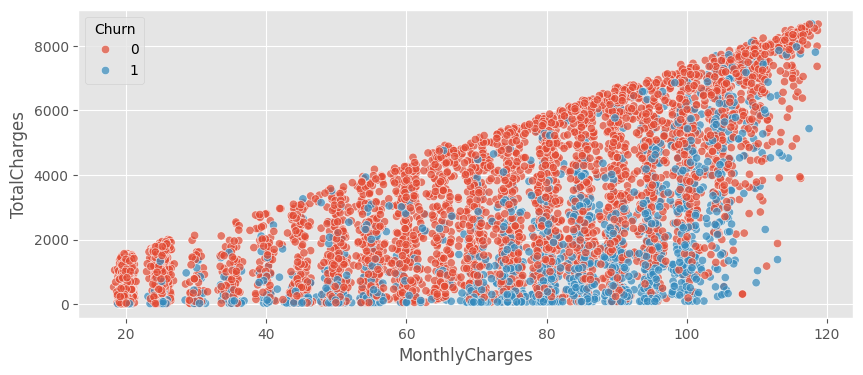

In [81]:
# 図の作成（横：10、縦：4）
plt.figure(figsize=(10,4))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.7)

####**(5) 数値データ（契約期間、月額料金）の関係を散布図で確認、かつ、解約状況も確認**

<Axes: xlabel='MonthlyCharges', ylabel='tenure'>

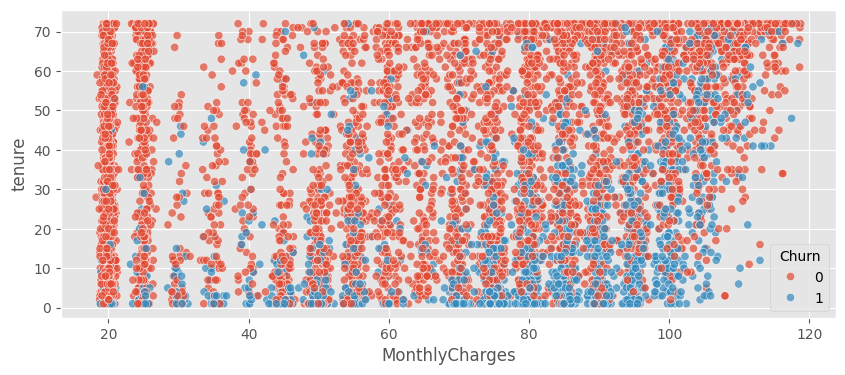

In [82]:
# 図の作成（横：10、縦：4）
plt.figure(figsize=(10,4))
sns.scatterplot(data=df, x='MonthlyCharges', y='tenure', hue='Churn', alpha=0.7)

####**(6) カテゴリカルデータの確認**

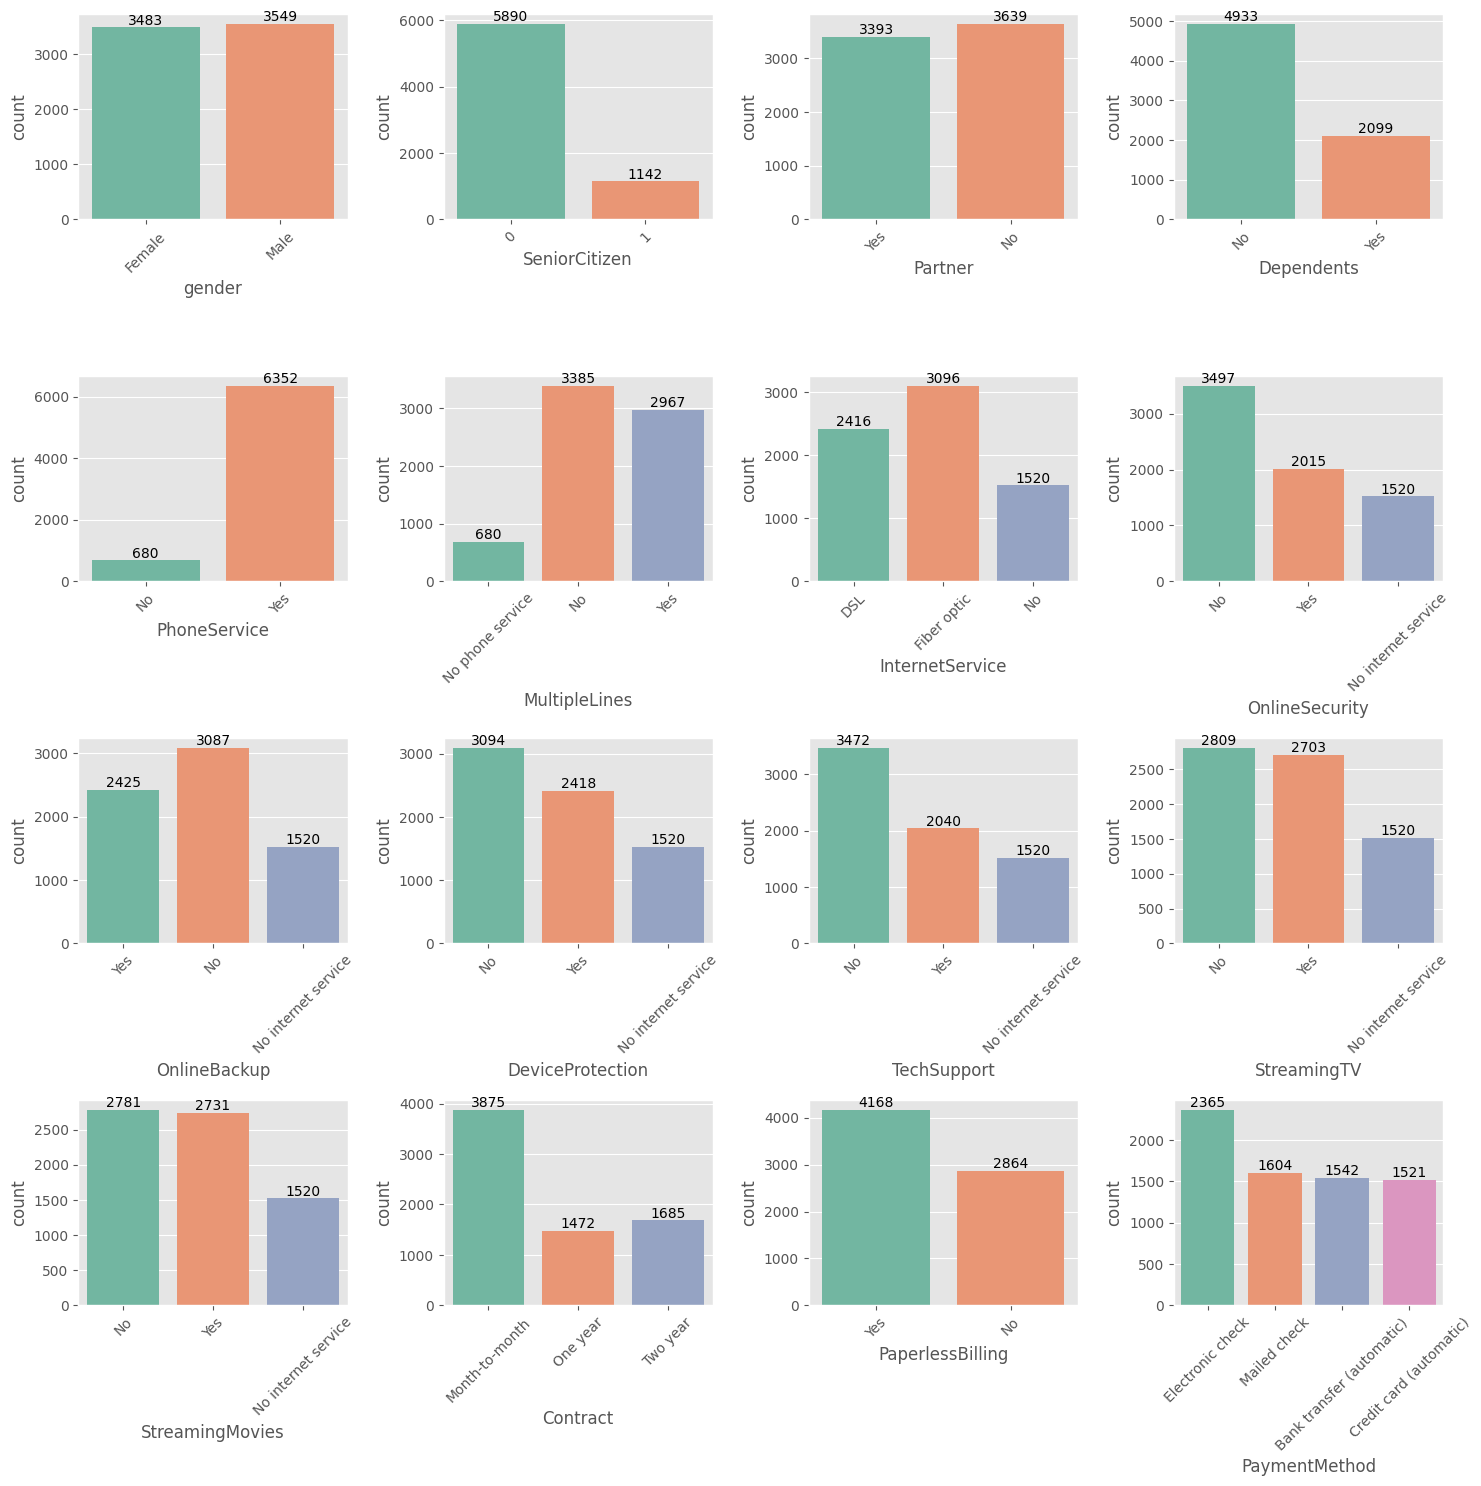

In [83]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

# 全体のフォントサイズ設定
plt.rc('font', size=12)

for n, variable in enumerate(cat_cols):
    ax = sns.countplot(data=df, x=variable, hue=variable, ax=axes[n], palette='Set2', legend=False)
    axes[n].tick_params(axis='x',rotation=45)

    # 棒グラフの上に件数を表示
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # 高さがゼロでない場合のみ表示
            ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

# 未使用のサブプロットを削除
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

# レイアウトを調整
plt.tight_layout()

# レイアウト調整（間隔広げる）
#plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()


####**(7) カテゴリカルデータ毎の解約を確認①**

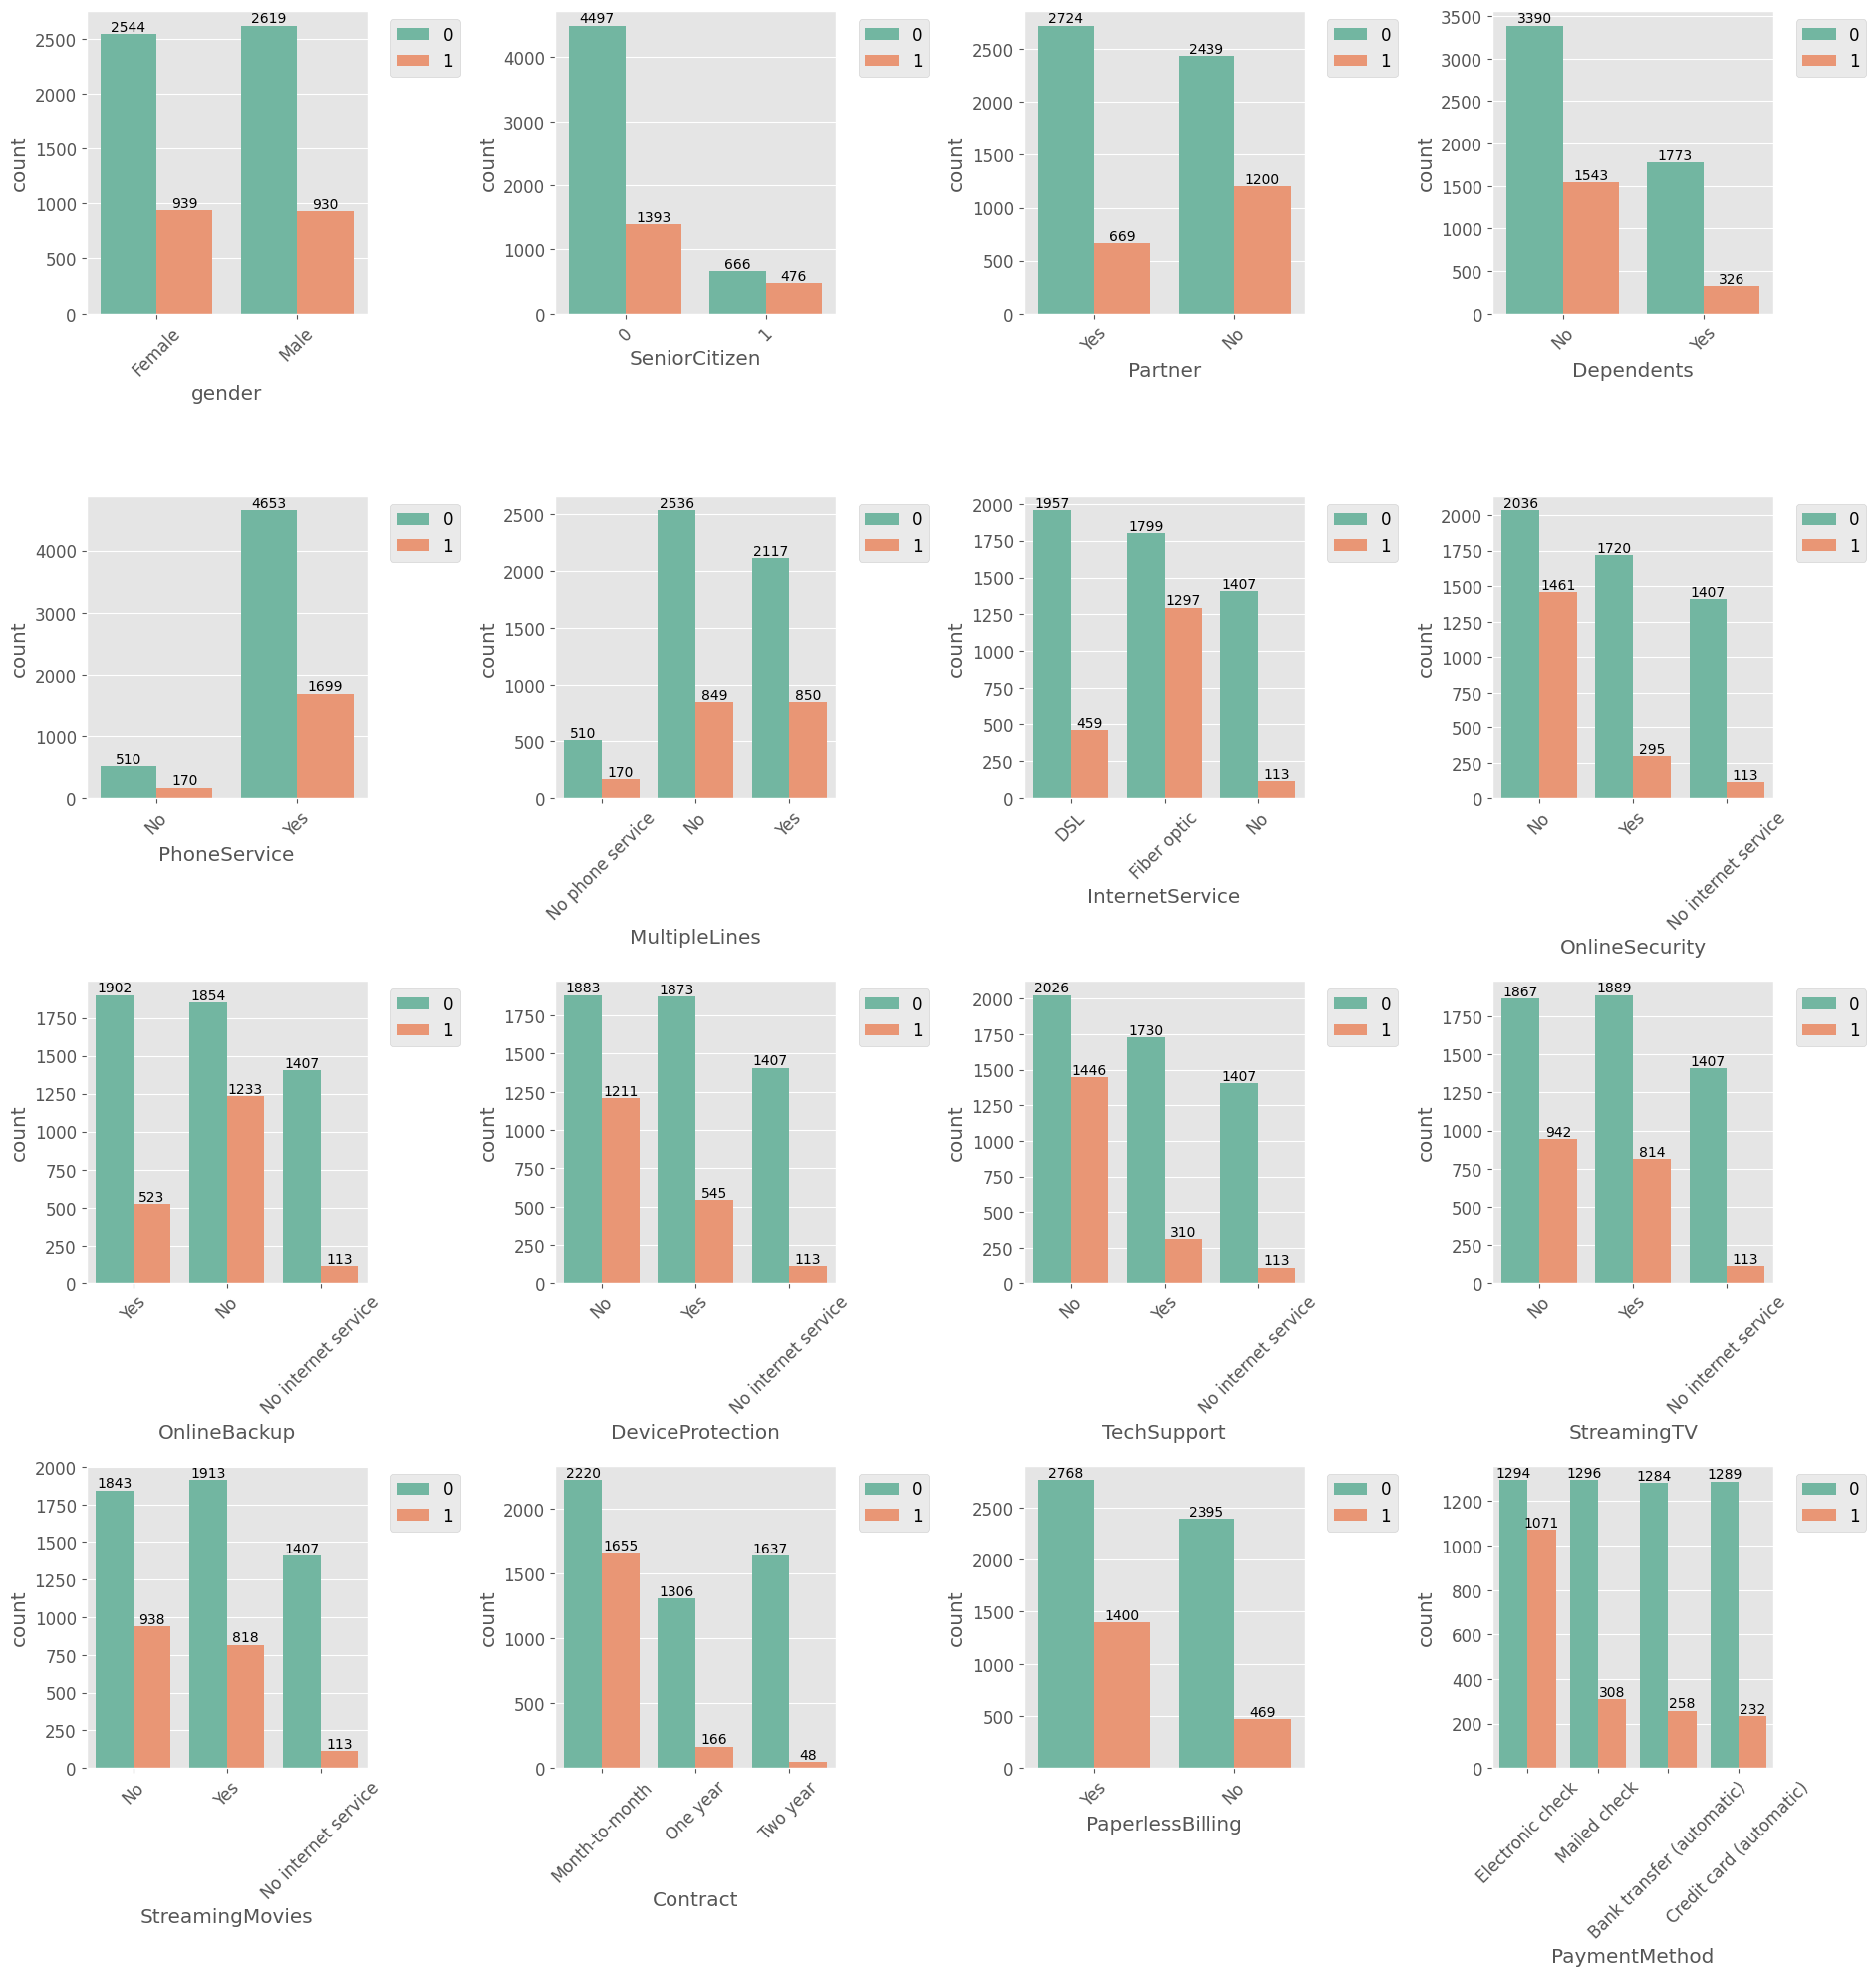

In [84]:
# 各特徴量の解約状況を確認
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

# 全体のフォントサイズ設定
plt.rc('font', size=12)

for n, variable in enumerate(cat_cols):
    ax = sns.countplot(data=df, x=variable, hue='Churn', ax=axes[n], palette='Set2')
    axes[n].tick_params(axis='x',rotation=45)

    # 凡例を右側に配置
    axes[n].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # 棒グラフの上に件数を表示
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # 高さがゼロでない場合のみ表示
            ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

# 未使用のサブプロットを削除
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

# レイアウト調整①（グラフ間の間隔を調整）
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# レイアウト調整②（右側の凡例用にスペースを入れる調整）
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()


####**(8) カテゴリカルデータ毎の解約を確認②**

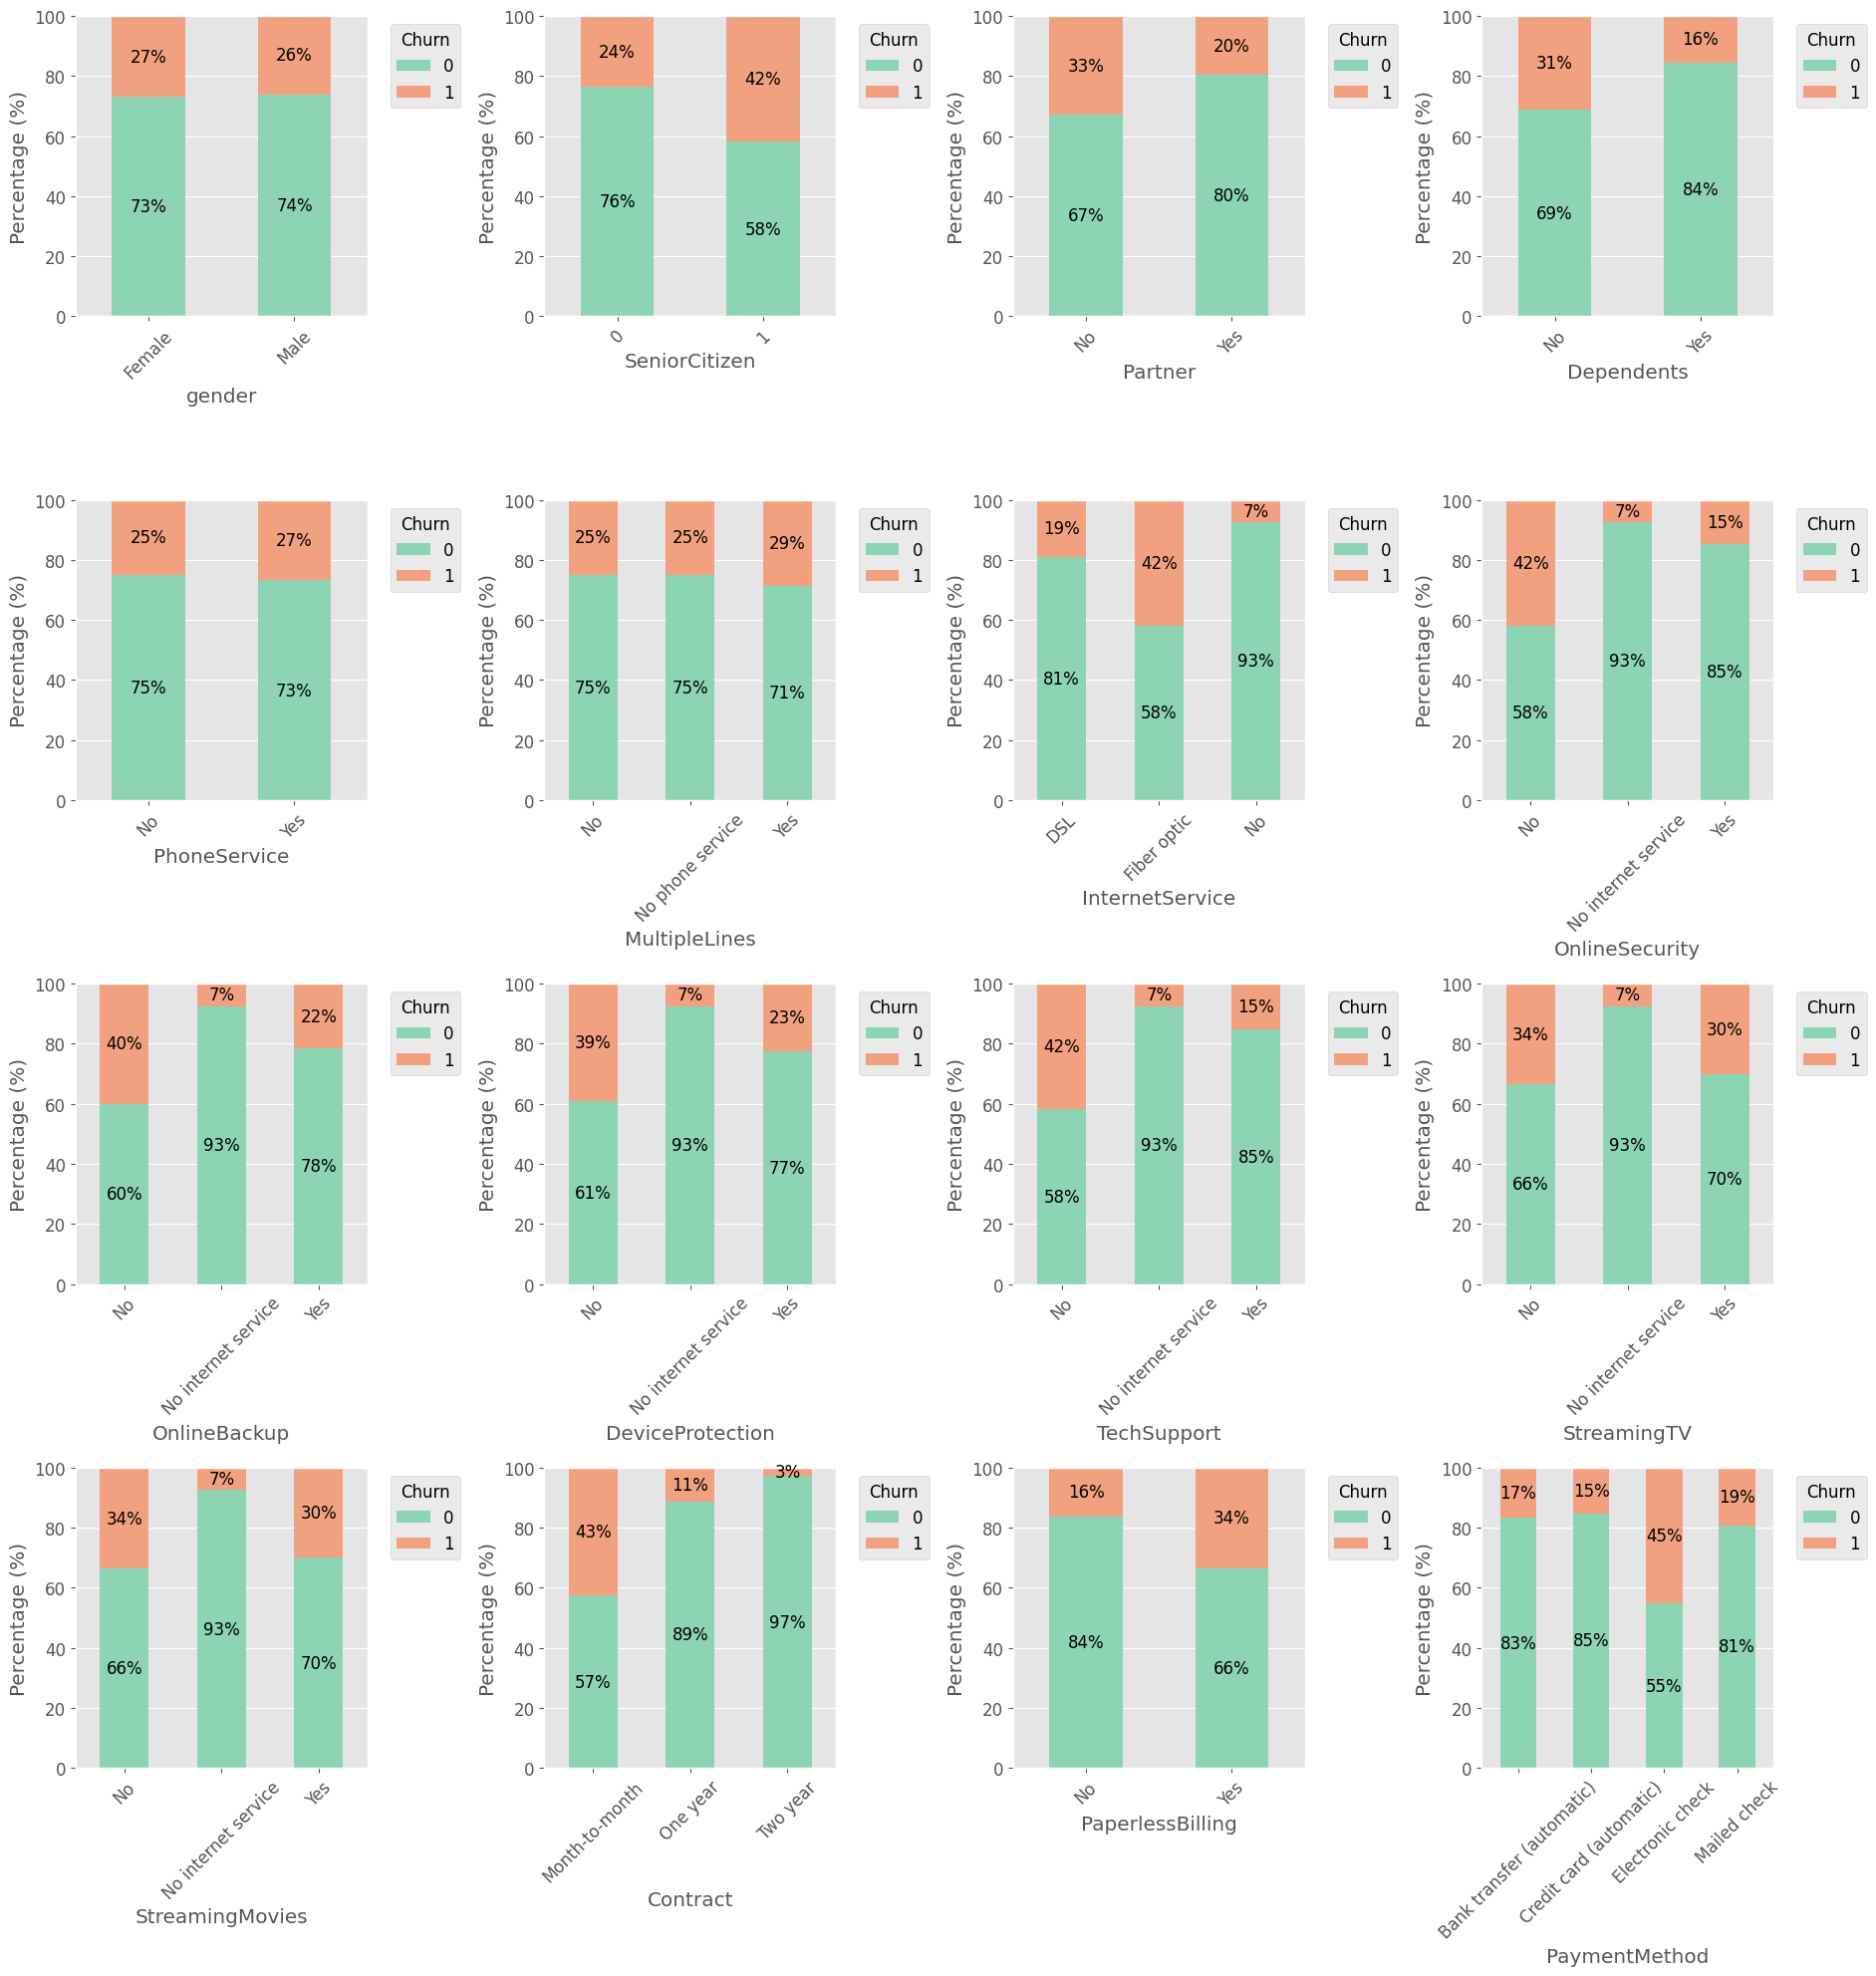

In [85]:
# 各特徴量の解約状況を確認
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

# 全体のフォントサイズ設定
plt.rc('font', size=12)

for n, variable in enumerate(cat_cols):
    # 各変数の割合を計算
    proportions = df.groupby([variable, 'Churn']).size().unstack(fill_value=0)
    proportions_pct = proportions.div(proportions.sum(axis=1), axis=0) * 100

    # プロット作成
    proportions_pct.plot(kind='bar', stacked=True, ax=axes[n],
                        color=['#8CD4B4', '#F1A17F'])  # Set2パレットの色に近い色を指定

    axes[n].set_ylabel('Percentage (%)')
    axes[n].tick_params(axis='x', rotation=45)

    # y軸の範囲を0-100に設定
    axes[n].set_ylim(0, 100)

    # パーセンテージの表示
    for c in axes[n].containers:
        axes[n].bar_label(c, fmt='%.0f%%', label_type='center')

    # 凡例を右側に配置
    axes[n].legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

# 未使用のサブプロットを削除
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

# グラフ間の間隔を調整
plt.subplots_adjust(wspace=0.4, hspace=0.4)

# レイアウトを調整（右側の凡例用にスペースを確保）
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

####**(9) カテゴリカルデータ毎の解約を確認③**

In [86]:
# 特徴量ごとのチャーン率を計算して表示する関数
def calculate_and_display_churn_rate(df, features):
    for feature in features:
        churn_rate = df.groupby(feature)['Churn'].mean().sort_values(ascending=False)
        print(f"\n## {feature}によるチャーン率\n")
        print("| カテゴリー | チャーン率 |")
        print("|------------|------------|")
        for category, rate in churn_rate.items():
            print(f"| {category} | {rate:.2%} |")
        print()

# 分析する特徴量のリスト
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# チャーン率を計算して表示
calculate_and_display_churn_rate(df, cat_cols)



## genderによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------|
| Female | 26.96% |
| Male | 26.20% |


## SeniorCitizenによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------|
| 1 | 41.68% |
| 0 | 23.65% |


## Partnerによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------|
| No | 32.98% |
| Yes | 19.72% |


## Dependentsによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------|
| No | 31.28% |
| Yes | 15.53% |


## PhoneServiceによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------|
| Yes | 26.75% |
| No | 25.00% |


## MultipleLinesによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------|
| Yes | 28.65% |
| No | 25.08% |
| No phone service | 25.00% |


## InternetServiceによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------|
| Fiber optic | 41.89% |
| DSL | 19.00% |
| No | 7.43% |


## OnlineSecurityによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------|
| No | 41.78% |
| Yes | 14.64% |
| No internet service | 7.43% |


## OnlineBackupによるチャーン率

| カテゴリー | チャーン率 |
|------------|------------